In [19]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from functools import partial
from einops import rearrange
from scipy.interpolate import RectBivariateSpline
from scipy.ndimage import gaussian_filter
from tqdm.notebook import tqdm

import sys
sys.path.append("../")

from utils import create_mask as cm
from utils.pdf_sampler import PDFSampler
from models.psf import KingPSF

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
import matplotlib.pylab as pylab
import warnings
import matplotlib.cbook

from plot_params import params

warnings.filterwarnings("ignore",category=matplotlib.cbook.mplDeprecation)

pylab.rcParams.update(params)
cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [21]:
from reproject import reproject_from_healpix, reproject_to_healpix
from astropy.wcs import WCS
from astropy.coordinates import ICRS, Galactic

In [22]:
from utils.cart import make_wcs, to_cart

In [23]:
cmap = 'RdBu_r'

In [24]:
! nvidia-smi

Thu May 12 13:46:20 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 470.57.02    Driver Version: 470.57.02    CUDA Version: 11.4     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla V100-PCIE...  On   | 00000000:06:00.0 Off |                    0 |
| N/A   38C    P0    36W / 250W |  29883MiB / 32510MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  Tesla V100-PCIE...  On   | 00000000:2F:00.0 Off |                    0 |
| N/A   

## Fermi data

In [25]:
from astropy.io import fits

counts_fits = fits.open("/n/holyscratch01/iaifi_lab/yitians/ccube_ultracleanveto_bestpsf_joined.fits")

pixel_size_data = 0.1
pixel_size_target = 0.5
extent = 25
i_e = 40

upsample_factor = int(pixel_size_target / pixel_size_data)

counts = counts_fits[0].data[i_e:i_e + 11].sum(0)[int((90 - extent) / 0.1):int((90 + extent) / 0.1),int((90 - extent) / 0.1):int((90 + extent) / 0.1)]
b = counts.shape[0] // upsample_factor
counts_downsampled = counts.reshape(-1, upsample_factor, b, upsample_factor).sum((-1, -3))

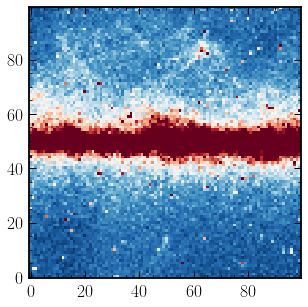

In [26]:
plt.imshow(counts_downsampled, vmax=100, cmap=cmap, origin='lower')

## Templates

In [27]:
extent = 25
n_pixels = 100
pixelsize = 2 * extent / n_pixels
upsample_factor = 4
nside = 128
sigma_psf = 0.2

In [28]:
fermi_data_cart = to_cart(np.load("../data/fermi_data/fermidata_counts.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

# Load standard templates
temp_gce_cart = to_cart(np.load("../data/fermi_data/template_gce.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dif_cart = to_cart(np.load("../data/fermi_data/template_dif.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_psc_cart = to_cart(np.load("../data/fermi_data/template_psc.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_iso_cart = to_cart(np.load("../data/fermi_data/template_iso.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dsk_cart = to_cart(np.load("../data/fermi_data/template_dsk.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_bub_cart = to_cart(np.load("../data/fermi_data/template_bub.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
mask_ps = np.load("../data/fermi_data/fermidata_pscmask.npy") == 1

# Load Model O templates
temp_mO_pibrem_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_pibrem.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_mO_ics_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_ics.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=60., custom_mask=mask_ps), n_pixels=n_pixels, pixelsize=pixelsize) > 0
mask_plane = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=60.,), n_pixels=n_pixels, pixelsize=pixelsize) > 0


In [29]:
np.max(counts_downsampled[~mask_roi])

278

## Poisson fits

In [30]:
from scipy.optimize import minimize

In [31]:
temp_ary = np.array([temp_gce_cart, temp_dif_cart, temp_psc_cart, temp_iso_cart, temp_dsk_cart, temp_bub_cart])

In [32]:
theta_ary = np.ones(temp_ary.shape[0])
temp_ary.shape

(6, 100, 100)

In [33]:
np.einsum("ik, i -> k", temp_ary[:, ~mask_plane], theta_ary)

array([1.73177416, 1.74818281, 1.76280524, ..., 1.81969318, 1.80381166,
       1.7914783 ])

In [35]:
from scipy.stats import poisson

def likelihood(theta, data, mask=None):
    if mask is None:
        mask = np.zeros(temp_ary[0].shape, dtype=bool)
    temp_sum = np.einsum("ik, i -> k", temp_ary[:, ~mask], theta)
    return -poisson.logpmf(data[~mask], temp_sum).mean()

## No mask

In [36]:
from tqdm import tqdm

x_test = np.load("../data/samples/x_test.npy")

In [129]:
ll_data = -minimize(likelihood, x0=np.ones(len(temp_ary)), args=(counts_downsampled)).fun

ll_sims = []
for x in tqdm(x_test[:100]):
    ll_sims.append(-minimize(likelihood, x0=np.ones(len(temp_ary)), args=(x)).fun)

100%|██████████| 100/100 [00:39<00:00,  2.56it/s]


In [141]:
ll_sims = np.array(ll_sims)
ll_sims = ll_sims[~np.isnan(ll_sims)]

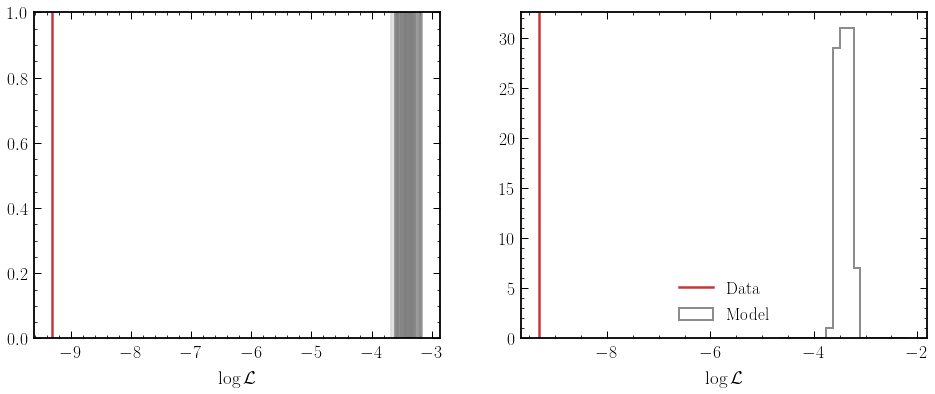

In [142]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

for sim in ll_sims:
    ax[0].axvline(sim, color='grey', alpha=0.3)

ax[0].axvline(ll_data)
ax[0].set_xlabel(r"$\log\mathcal L$")

ax[1].hist(np.array(ll_sims), bins=np.linspace(np.min(ll_sims) - 1., np.max(ll_sims) + 1., 20), histtype='step', color='grey', label="Model", lw=2)
ax[1].axvline(ll_data, label="Data")
ax[1].set_xlabel(r"$\log\mathcal L$")
ax[1].legend()

## With plane mask

In [143]:
ll_data = -minimize(likelihood, x0=np.ones(len(temp_ary)), args=(counts_downsampled, mask_plane)).fun

ll_sims = []
for x in tqdm(x_test[:100]):
    ll_sims.append(-minimize(likelihood, x0=np.ones(len(temp_ary)), args=(x, mask_plane)).fun)

100%|██████████| 100/100 [00:41<00:00,  2.42it/s]


In [144]:
ll_sims = np.array(ll_sims)
ll_sims = ll_sims[~np.isnan(ll_sims)]

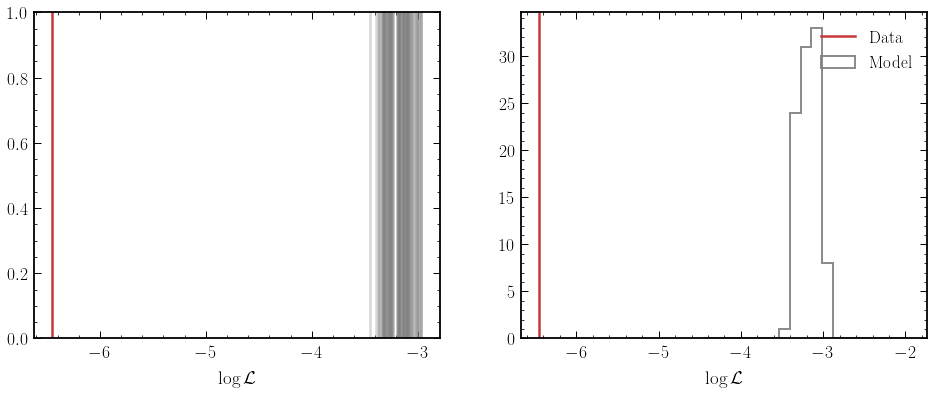

In [145]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

for sim in ll_sims:
    ax[0].axvline(sim, color='grey', alpha=0.3)

ax[0].axvline(ll_data)
ax[0].set_xlabel(r"$\log\mathcal L$")

ax[1].hist(np.array(ll_sims), bins=np.linspace(np.min(ll_sims) - 1., np.max(ll_sims) + 1., 20), histtype='step', color='grey', label="Model", lw=2)
ax[1].axvline(ll_data, label="Data")
ax[1].set_xlabel(r"$\log\mathcal L$")
ax[1].legend()

## With ROI mask

In [37]:
ll_data = -minimize(likelihood, x0=np.ones(len(temp_ary)), args=(counts_downsampled, mask_roi)).fun

ll_sims = []
for x in tqdm(x_test[:100]):
    ll_sims.append(-minimize(likelihood, x0=np.ones(len(temp_ary)), args=(x, mask_roi)).fun)

100%|██████████| 100/100 [00:43<00:00,  2.28it/s]


In [38]:
ll_sims = np.array(ll_sims)
ll_sims = ll_sims[~np.isnan(ll_sims)]

In [40]:
-0.5 * np.sum(~mask_roi)

-3829.5

In [60]:
np.percentile(np.log(x_test[:, ~mask_roi].mean(-1)), [5., 95.])

array([2.92584314, 3.34829947])

(array([ 7., 18., 37., 57., 68., 84., 92., 72., 50., 15.]),
 array([2.79292819, 2.85664585, 2.92036352, 2.98408118, 3.04779885,
        3.11151651, 3.17523418, 3.23895184, 3.30266951, 3.36638717,
        3.43010484]),
 <BarContainer object of 10 artists>)

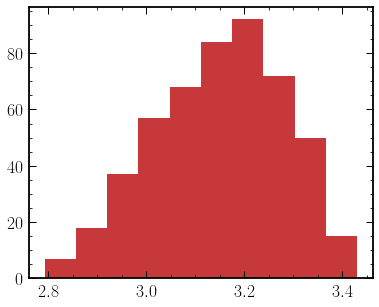

In [58]:
plt.hist(np.log(x_test[:, ~mask_roi].mean(-1)))

In [48]:
np.mean(np.log(2 * np.pi * counts_downsampled[~mask_roi] + 1e-10))

4.773838752973838

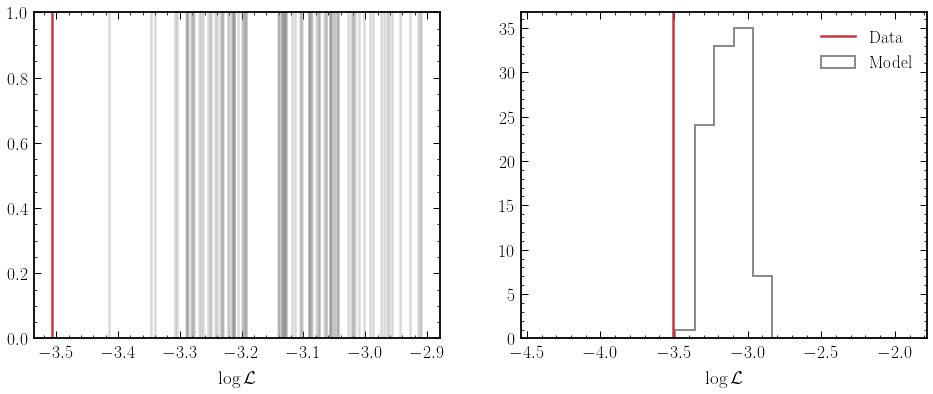

In [49]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

for sim in ll_sims:
    ax[0].axvline(sim, color='grey', alpha=0.3)

ax[0].axvline(ll_data)
ax[0].set_xlabel(r"$\log\mathcal L$")

ax[1].hist(np.array(ll_sims), bins=np.linspace(np.min(ll_sims) - 1., np.max(ll_sims) + 1., 20), histtype='step', color='grey', label="Model", lw=2)
ax[1].axvline(ll_data, label="Data")
ax[1].set_xlabel(r"$\log\mathcal L$")
ax[1].legend()

## Fit to real data

In [ ]:
from jax import random
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.distributions import constraints
from numpyro.infer import Predictive, SVI, Trace_ELBO, RenyiELBO
from numpyro.infer.autoguide import AutoIAFNormal, AutoMultivariateNormal, AutoDiagonalNormal, AutoLaplaceApproximation, AutoBNAFNormal
from jax.lax import scan
import jax.lax as lax

def model(data, rng_key=random.PRNGKey(13)):
    
    theta_gce = numpyro.sample("theta_gce", dist.Uniform(0., 20.), rng_key=rng_key)
    theta_iso = numpyro.sample("theta_iso", dist.Uniform(0., 20.), rng_key=rng_key)
    theta_bub = numpyro.sample("theta_bub", dist.Uniform(0., 20.), rng_key=rng_key)
    theta_psc = numpyro.sample("theta_psc", dist.Uniform(0., 20.), rng_key=rng_key)
    theta_pibrem = numpyro.sample("theta_pibrem", dist.Uniform(0., 40.), rng_key=rng_key)
    theta_ics = numpyro.sample("theta_ics", dist.Uniform(0., 20.), rng_key=rng_key)
    
    mu = temp_gce_cart * theta_gce + \
        temp_iso_cart * theta_iso + \
        temp_bub_cart * theta_bub + \
        temp_psc_cart * theta_psc + \
        temp_mO_pibrem_cart * theta_pibrem + \
        temp_mO_ics_cart * theta_ics
    
    
    data = data.reshape(-1, data.shape[-1] * data.shape[-2])
    mu = mu.reshape(-1, data.shape[-1] * data.shape[-2])
    
    with numpyro.plate("data_plate", data.shape[-1]):
        return numpyro.sample("obs", dist.Poisson(mu), obs=data, rng_key=rng_key)


/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/jax/experimental/optimizers.py:28: FutureWarning: jax.experimental.optimizers is deprecated, import jax.example_libraries.optimizers instead
  warnings.warn('jax.experimental.optimizers is deprecated, '
/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/jax/experimental/stax.py:28: FutureWarning: jax.experimental.stax is deprecated, import jax.example_libraries.stax instead
  warnings.warn('jax.experimental.stax is deprecated, '


In [73]:
from numpyro.infer import MCMC, HMC, NUTS

kernel = NUTS(model, target_accept_prob=0.9)
mcmc = MCMC(kernel, num_warmup=1000, num_samples=3200)
mcmc.run(rng_key=random.PRNGKey(0), data=counts_downsampled)

mcmc.print_summary()

sample: 100%|█| 4200/4200 [00:46<00:00, 90.53it/s, 15 steps of size 3.21e-01. acc. prob=



                    mean       std    median      5.0%     95.0%     n_eff     r_hat
     theta_bub      0.65      0.04      0.65      0.58      0.71   2647.21      1.00
     theta_gce      2.49      0.06      2.49      2.39      2.59   2555.06      1.00
     theta_ics      6.54      0.10      6.54      6.37      6.70   2333.48      1.00
     theta_iso      0.01      0.01      0.00      0.00      0.01   3595.91      1.00
  theta_pibrem     19.87      0.06     19.87     19.77     19.97   2714.45      1.00
     theta_psc      0.20      0.01      0.20      0.18      0.21   3009.03      1.00

Number of divergences: 0
